# Classifiers

In this notebook, we shall implement and observe dimensionality reduction techniques like PCA and LDA to find linear seperability.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X = df.iloc[:, :12]
y = df.iloc[:, 12]

feature_names = [f'c{i+1}' for i in range(12)]
X.columns = feature_names

class_1 = X[y == 1.0]  # Relaxed
class_2 = X[y == 2.0]  # Planning

### PCA

Variance explained by top 2 components: 46.30%


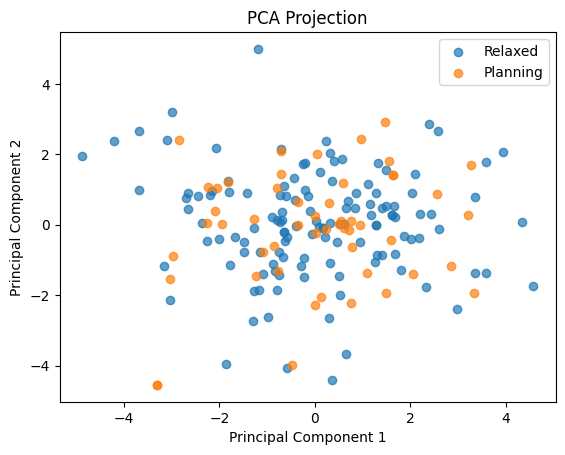

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = y.values


print(
    f"Variance explained by top 2 components: {pca.explained_variance_ratio_.sum():.2%}"
)

plt.scatter(
    pca_df[pca_df["Class"] == 1.0]["PC1"],
    pca_df[pca_df["Class"] == 1.0]["PC2"],
    label="Relaxed",
    alpha=0.7,
)
plt.scatter(
    pca_df[pca_df["Class"] == 2.0]["PC1"],
    pca_df[pca_df["Class"] == 2.0]["PC2"],
    label="Planning",
    alpha=0.7,
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.title("PCA Projection")
plt.show()

### LDA

Explained variance ratio: 100.00%


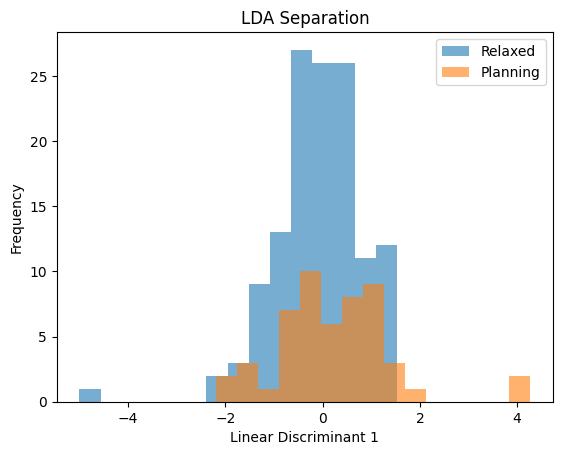

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

lda_df = pd.DataFrame(X_lda, columns=["LD1"])
lda_df["Class"] = y.values

print(f"Explained variance ratio: {lda.explained_variance_ratio_[0]:.2%}")

plt.hist(
    lda_df[lda_df["Class"] == 1.0]["LD1"],
    alpha=0.6,
    label="Relaxed",
    bins=15,
)
plt.hist(
    lda_df[lda_df["Class"] == 2.0]["LD1"],
    alpha=0.6,
    label="Planning",
    bins=15,
)
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Frequency")
plt.legend()
plt.title("LDA Separation")
plt.show()

## LDA in classification pipeline

We can observe the below code's result

In [10]:
df.groupby(12).count()

,0,1,2,3,4,5,6,7,8,9,10,11,13
12,,,,,,,,,,,,,
1.0,130,130,130,130,130,130,130,130,130,130,130,130,0
2.0,52,52,52,52,52,52,52,52,52,52,52,52,0


Due to the apparent class imbalance, we will now design a classification pipeline which will 

- Oversample the result
- Makes sure the oversampling doesnt leak to the training set
- Performs 5-fold cross validation

--- 5-Fold CV Performance (LDA + SMOTE) ---
Accuracy  : 0.4509 (± 0.0586)
Precision : 0.6563 (± 0.0510)
Recall    : 0.4846 (± 0.1104)
F1        : 0.5518 (± 0.0748)
Roc_auc   : 0.3485 (± 0.0411)
Confusion Matrix:
 [[63 67]
 [33 19]]


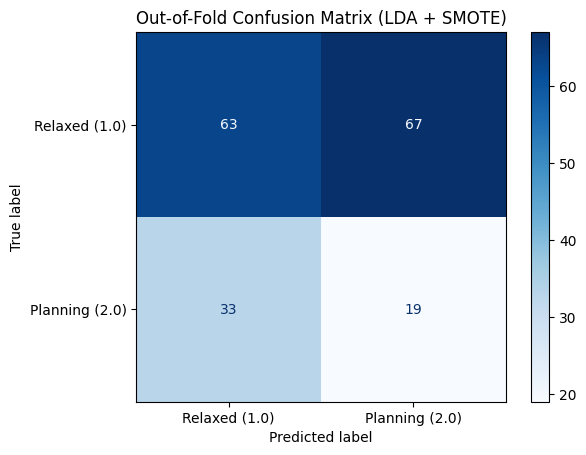

In [16]:
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("oversampler", SMOTE(random_state=42)),
        ("lda", LinearDiscriminantAnalysis()),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
)

print("--- 5-Fold CV Performance (LDA + SMOTE) ---")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.capitalize():<10}: {scores.mean():.4f} (± {scores.std():.4f})")

y_pred = cross_val_predict(pipeline, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

labels = ["Relaxed (1.0)", "Planning (2.0)"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Out-of-Fold Confusion Matrix (LDA + SMOTE)")
plt.show()

--- 5-Fold CV Performance (LDA + SMOTE) ---
Accuracy  : 0.4509 (± 0.0586)
Precision : 0.6563 (± 0.0510)
Recall    : 0.4846 (± 0.1104)
F1        : 0.5518 (± 0.0748)
Roc_auc   : 0.3485 (± 0.0411)
Confusion Matrix:
 [[63 67]
 [33 19]]


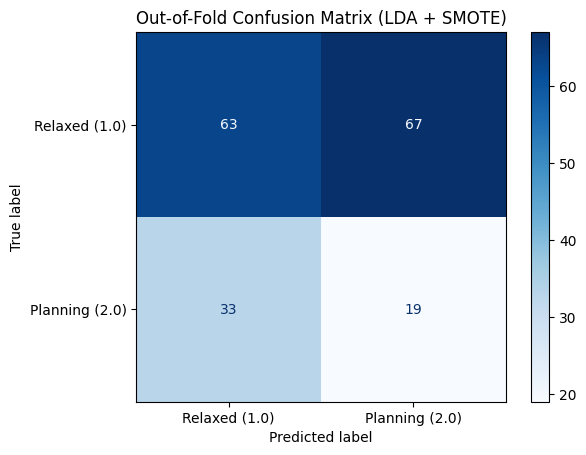

## SVM + SMOTE

--- 5-Fold CV Performance (SVM + SMOTE) ---
Accuracy  : 0.6104 (± 0.0427)
Precision : 0.7370 (± 0.0363)
Recall    : 0.7077 (± 0.0576)
F1        : 0.7208 (± 0.0375)
Roc_auc   : 0.4846 (± 0.0723)
Confusion Matrix:
[[92 38]
 [33 19]]


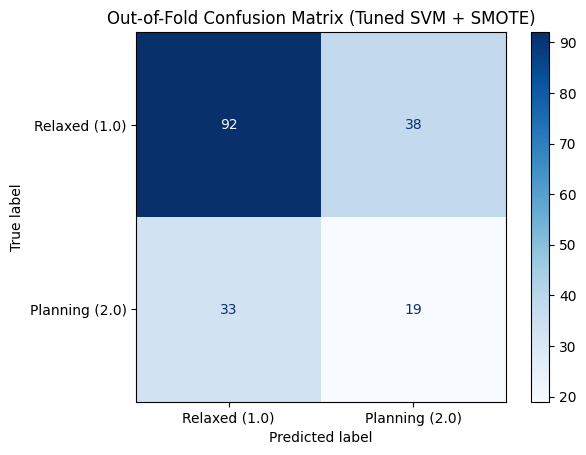

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("oversampler", SMOTE(random_state=42)),
        ("svm", SVC(probability=True, random_state=42)),
    ]
)

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.1],
    "svm__kernel": ["rbf", "linear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search.fit(X, y)

best_pipeline = grid_search.best_estimator_
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    best_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
)

y_pred = cross_val_predict(best_pipeline, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)

print("--- 5-Fold CV Performance (SVM + SMOTE) ---")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.capitalize():<10}: {scores.mean():.4f} (± {scores.std():.4f})")

print(f"Confusion Matrix:\n{cm}")

labels = ["Relaxed (1.0)", "Planning (2.0)"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Out-of-Fold Confusion Matrix (Tuned SVM + SMOTE)")
plt.show()

## KNN + SMOTE

Here, we attempt to capture non linear features using KNN

--- 5-Fold CV Performance (KNN + SMOTE) ---
Accuracy  : 0.4728 (± 0.0720)
Precision : 0.7182 (± 0.0662)
Recall    : 0.4231 (± 0.0910)
F1        : 0.5298 (± 0.0858)
Roc_auc   : 0.5503 (± 0.0716)
Confusion Matrix: 
[[55 75]
 [21 31]]


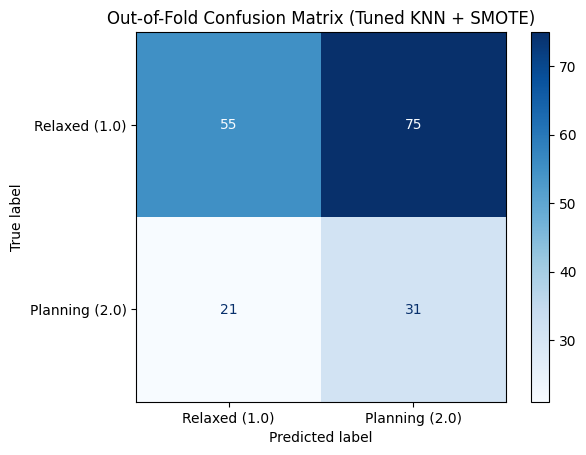

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("oversampler", SMOTE(random_state=42)),
        ("knn", KNeighborsClassifier()),
    ]
)

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
grid_search.fit(X, y)

best_pipeline = grid_search.best_estimator_
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    best_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
)

y_pred = cross_val_predict(best_pipeline, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)

print("--- 5-Fold CV Performance (KNN + SMOTE) ---")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.capitalize():<10}: {scores.mean():.4f} (± {scores.std():.4f})")

print(f"Confusion Matrix: \n{cm}")

labels = ["Relaxed (1.0)", "Planning (2.0)"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Out-of-Fold Confusion Matrix (Tuned KNN + SMOTE)")
plt.show()